# CS180 Project 2

Date: 9/26/25

# Table of Contents

- [Part 1](#part-1)
  - [1.1](#11)
  - [1.2](#12)
  - [1.3](#13)
- [Part 2](#part-2)
  - [2.1](#21)
  - [2.2](#22)

Imports and helpful functions

In [1]:
import numpy as np
# Fix matplotlib backend issues
# import matplotlib
# matplotlib.use('Agg')  # Use non-GUI backend
import matplotlib.pyplot as plt
import scipy
import skimage as sk
import skimage.io as skio
import scipy
import sys
#import cv2
import os

def save_output_im(im_out, fname):  
    """Saves an image and outputs it

    Inputs:
        im_out: Stacked image in (H x W x 3) (r g b)
        fname name of file
    """
    # save the image
    fname = f'../images/{fname}.jpg'
    if im_out.dtype == np.float64:
        im_out = (im_out * 255).astype(np.uint8)
    else:
        raise ValueError(f"Invalid image type {im_out.dtype}")
    skio.imsave(fname,im_out, as_gray = True)
    

### Part 1

#### 1.1

To see the implementation of convolutions, please refer to `./convolve.py`

In [2]:
#import convolution functions
from convolve import convolve2l, convolve4l

In [3]:
#read in the selfie
file = '../images/selfie.jpeg'
im = skio.imread(file)
im = sk.img_as_float(im) 
im = sk.color.rgb2gray(im)

In [4]:
#Define the filters to use for the image
boxfilt = np.full((15,15), 1/(15**2))
Dx = np.array([1,0,-1]).reshape(1,3)
Dy = np.array([
    [1],
    [0],
    [-1]
    ])

In [5]:
# attempt Dx and Dy on selfie
selfieBox = convolve2l(im, boxfilt)
selfieDx = convolve2l(im, Dx)
selfieDy = convolve2l(im, Dy)

In [6]:
selfieDx.shape

(2316, 3088)

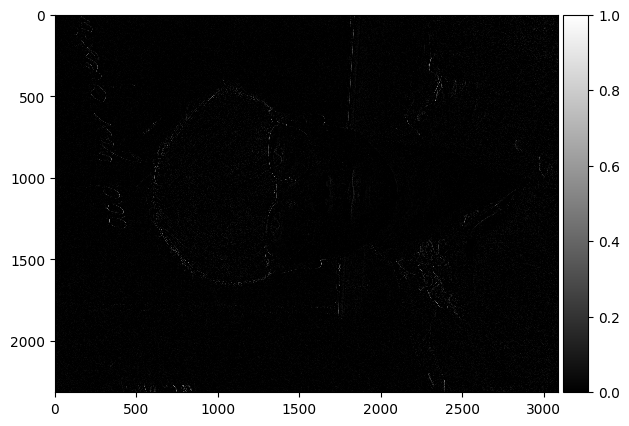

In [7]:
skio.imshow(selfieDx,vmin=0.0, vmax=1.0, cmap = 'gray')

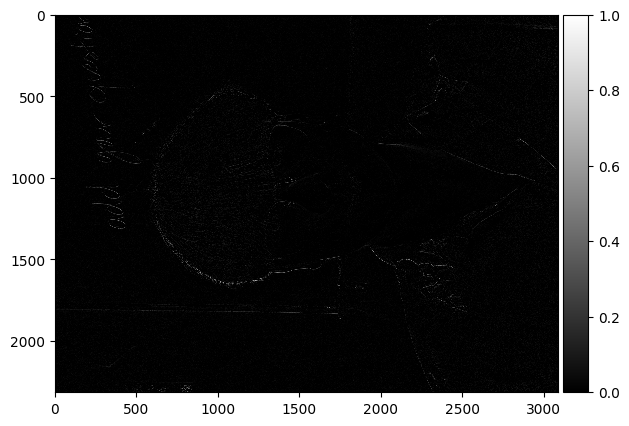

In [8]:
skio.imshow(selfieDy,vmin=0.0, vmax=1.0, cmap = 'gray')

In [9]:
#to save
# save_output_im(selfieBox," ../images/convolved_selfie.jpg")
# save_output_im(selfieDx," ../images/convolved_Dx_selfie.jpg")
# save_output_im(selfieDy," ../images/convolved_Dy_selfie.jpg")

#### 1.2

In [10]:
#begin binarization

#load cameraman
cameraman = skio.imread("../images/cameraman.png")
cameraman = sk.img_as_float(cameraman) 
cameraman = sk.color.rgba2rgb(cameraman)
cameraman = sk.color.rgb2gray(cameraman)

In [11]:
imDx = scipy.signal.convolve2d(cameraman, Dx, mode='same')
imDy = scipy.signal.convolve2d(cameraman, Dy, mode='same')

In [12]:
#save cameraman convolutions
# save_output_im(imDx,"../images/scipy_Dx_cameraman")
# save_output_im(imDy,"../images/scipy_Dy_cameraman")

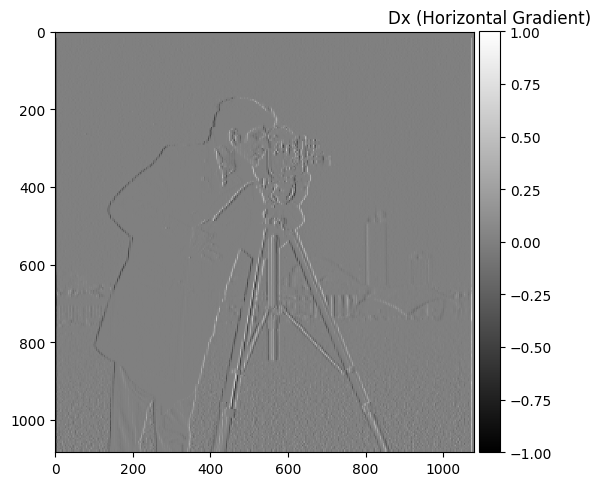

In [13]:
skio.imshow(imDx, cmap='gray', vmin=-1, vmax=1)
plt.title('Dx (Horizontal Gradient)')
plt.show()

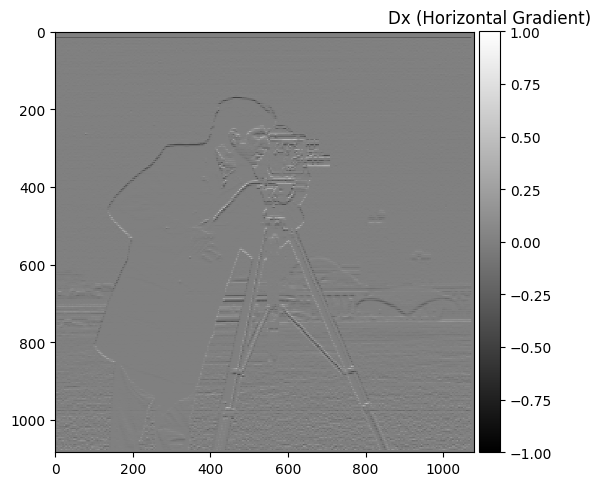

In [14]:
skio.imshow(imDy, cmap='gray', vmin=-1, vmax=1)
plt.title('Dx (Horizontal Gradient)')
plt.show()

c:\Users\123bi\miniconda3\envs\cs\lib\site-packages\skimage\io\_plugins\matplotlib_plugin.py:158: UserWarning: Float image out of standard range; displaying image with stretched contrast.
  lo, hi, cmap = _get_display_range(image)


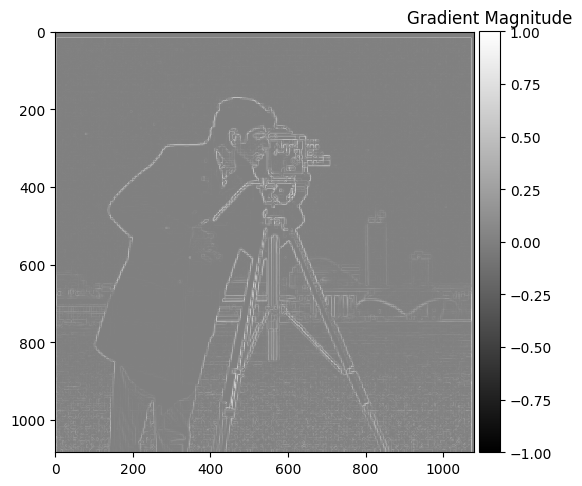

In [15]:
grad_mag = np.sqrt(np.power(imDx,2) + np.power(imDy,2))
skio.imshow(grad_mag, cmap='gray', vmin=-1, vmax=1)
plt.title('Gradient Magnitude')
plt.show()


In [16]:
# THRESHOLD = 0.6
for thresh in np.linspace(0.1,0.9,9):
    mask = grad_mag > thresh
    binarized = np.zeros(imDx.shape)
    binarized[mask] = 1
    #save_output_im(binarized,f"../images/binarized_{thresh}_cameraman")

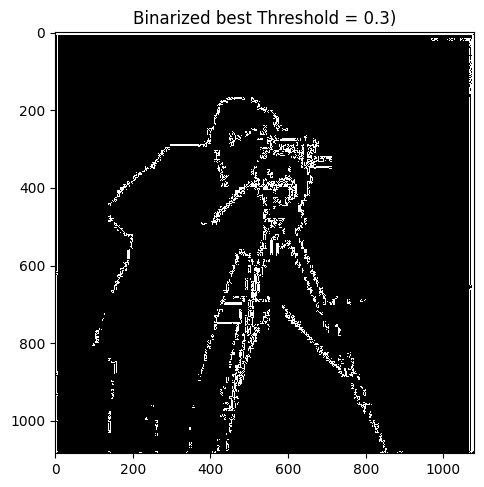

In [17]:
#show best
best_binarized = skio.imread("../images/binarized_0.3_cameraman.jpg", as_gray=True)
skio.imshow(best_binarized, cmap='gray', vmin=0, vmax=1)
plt.title('Binarized best Threshold = 0.3)')
plt.show()


#### 1.3

In [25]:
from scipy.ndimage import gaussian_filter
from scipy import signal

kernel_size = 15  # odd number
sigma = 2.0

# Create 2D Gaussian kernel using scipy
gaussian_2d = signal.windows.gaussian(kernel_size, sigma)
gaussian_2d = gaussian_2d.reshape(-1, 1) @ gaussian_2d.reshape(1, -1)
gaussian_2d = gaussian_2d / np.sum(gaussian_2d)  

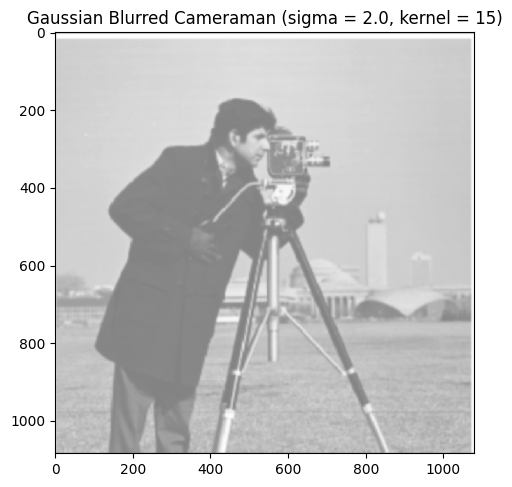

In [26]:
gauss_cameraman = scipy.signal.convolve2d(cameraman, gaussian_2d, mode = 'same')
skio.imshow(gauss_cameraman, cmap='gray', vmin=-1, vmax=1)
plt.title(f'Gaussian Blurred Cameraman (sigma = {sigma}, kernel = {kernel_size})')
plt.show()

In [27]:
imGDx = scipy.signal.convolve2d(gauss_cameraman, Dx, mode='same')
imGDy = scipy.signal.convolve2d(gauss_cameraman, Dy, mode='same')

In [28]:
# save_output_im(imGDx,"../images/scipy_GDx_cameraman")
# save_output_im(imGDy,"../images/scipy_GDy_cameraman")

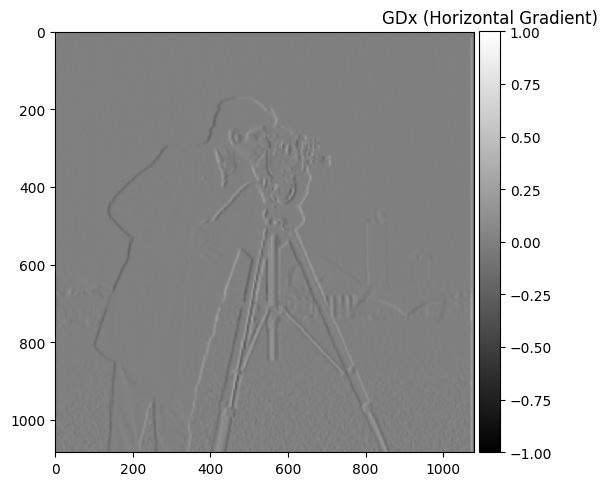

In [29]:
skio.imshow(imGDx, cmap='gray', vmin=-1, vmax=1)
plt.title('GDx (Horizontal Gradient)')
plt.show()

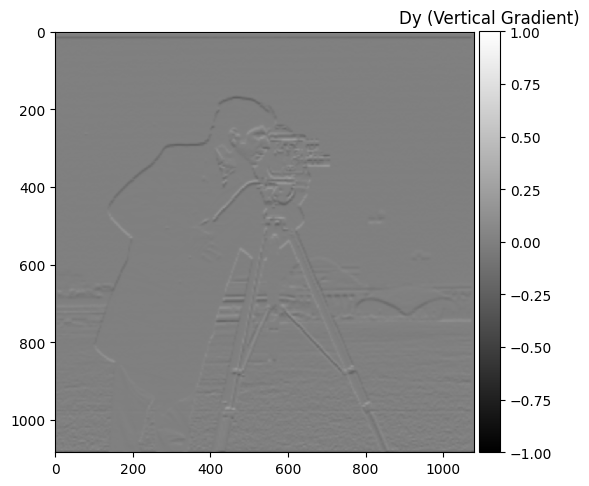

In [30]:
skio.imshow(imGDy, cmap='gray', vmin=-1, vmax=1)
plt.title('Dy (Vertical Gradient)')
plt.show()

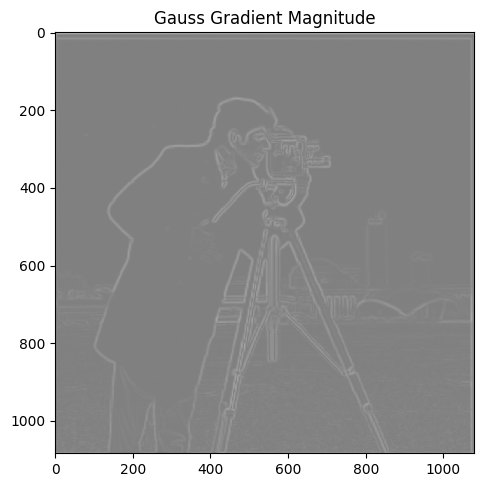

In [31]:
gauss_grad_mag = np.sqrt(np.power(imGDx,2) + np.power(imGDy,2))
skio.imshow(gauss_grad_mag, cmap='gray', vmin=-1, vmax=1)
plt.title('Gauss Gradient Magnitude')
plt.show()


In [32]:
for thresh in np.linspace(0.1,0.2,9):
    mask = gauss_grad_mag > thresh
    binarized = np.zeros(imGDx.shape)
    binarized[mask] = 1
    #save_output_im(binarized,f"../images/binarized_gauss_{thresh}_cameraman")

Interestingly, the best threshold is lower than what is was before (its around 1.5 i think). Reason as to why:

Other notes:
the gaussian is less spotty and has smoother edge detections

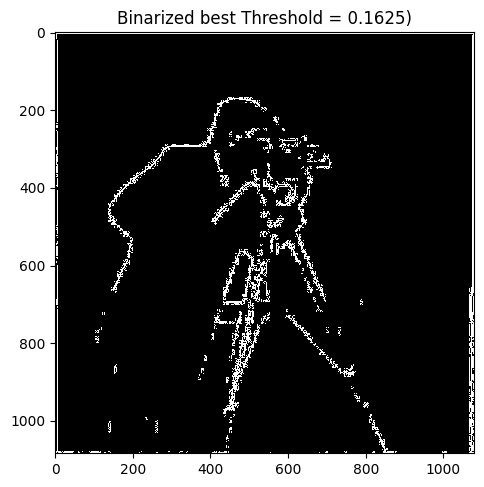

In [33]:
best_binarized = skio.imread("../images/binarized_gauss_0.1625_cameraman.jpg", as_gray=True)
skio.imshow(best_binarized, cmap='gray', vmin=0, vmax=1)
plt.title('Binarized best Threshold = 0.1625)')
plt.show()


Now Derive DoG and apply similarly.

In [34]:
DoGx = scipy.signal.convolve2d(gaussian_2d, Dx, mode = "same")
DoGy = scipy.signal.convolve2d(gaussian_2d, Dy, mode = 'same')

In [35]:
imGx = scipy.signal.convolve2d(cameraman, DoGx, mode='same')
imGy = scipy.signal.convolve2d(cameraman, DoGy, mode='same')

In [36]:
save_output_im(imGx,"../images/scipy_Gx_cameraman")
save_output_im(imGy,"../images/scipy_Gy_cameraman")

In [37]:
gauss_grad_mag = np.sqrt(np.power(imGx,2) + np.power(imGy,2))

THRESHOLD = 1.625
mask = gauss_grad_mag > THRESHOLD
binarized = np.zeros(imGDx.shape)
binarized[mask] = 1

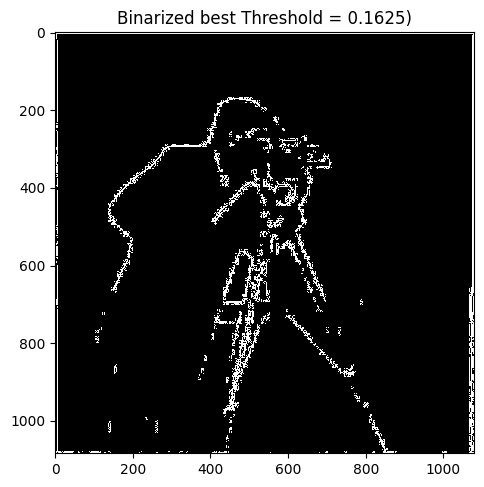

In [38]:
skio.imshow(best_binarized, cmap='gray', vmin=0, vmax=1)
plt.title('Binarized best Threshold = 0.1625)')
plt.show()

### Part 2

#### 2.1

In [39]:
taj =  skio.imread("../images/taj.png")
taj = sk.img_as_float(taj) 
taj = sk.color.rgba2rgb(taj)

In [40]:
#lowpass across all color channels
lowpass = np.zeros(taj.shape)
for color in range(taj.shape[2]):
    lowpass[:,:,color] = scipy.signal.convolve2d(taj[:,:,color], gaussian_2d, mode = 'same')

In [41]:
#highpass of taj
highpass = taj - lowpass
# Rescale highpass to [0, 1]
highpass_rescaled = (highpass - highpass.min()) / (highpass.max() - highpass.min())


In [42]:
#compute sharpened image
ALPHA = 3

sharpened = taj + (ALPHA * highpass)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.7733633896165888..2.164253718660965].


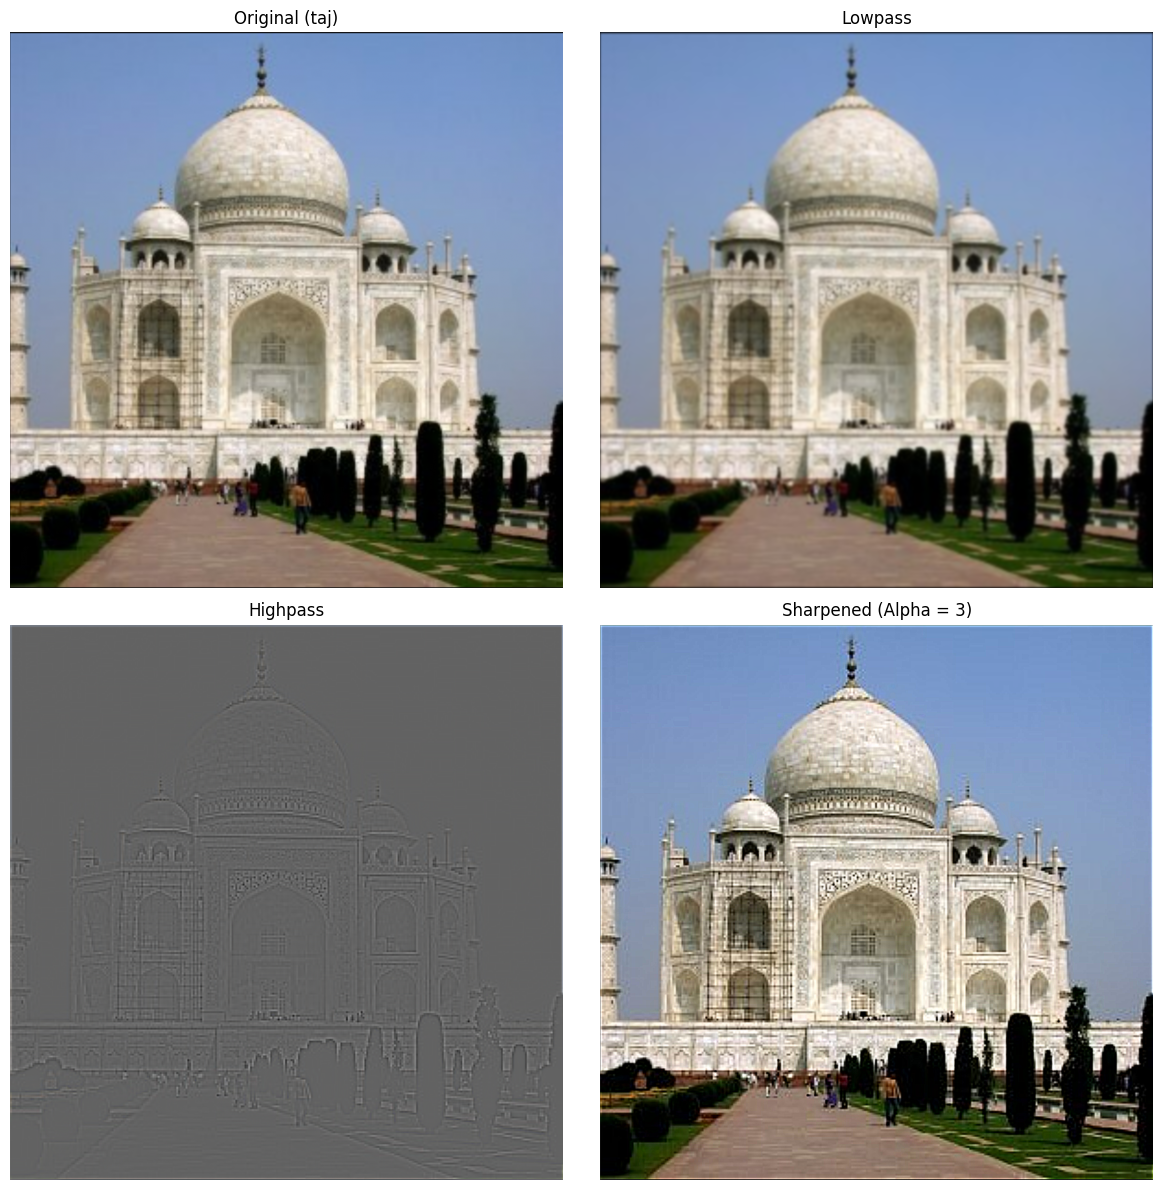

In [43]:
fig, axs = plt.subplots(2, 2, figsize=(12, 12))

axs[0,0].imshow(taj);               axs[0,0].set_title('Original (taj)');     axs[0,0].axis('off')
axs[0,1].imshow(lowpass);           axs[0,1].set_title('Lowpass');            axs[0,1].axis('off')
axs[1,0].imshow(highpass_rescaled); axs[1,0].set_title('Highpass');           axs[1,0].axis('off')
axs[1,1].imshow(sharpened);         axs[1,1].set_title(f'Sharpened (Alpha = {ALPHA})'); axs[1,1].axis('off')

plt.tight_layout()
plt.show()


In [44]:
#combining it all into one operation
unsharp_kernel = -ALPHA * gaussian_2d
center = gaussian_2d.shape[0] // 2
unsharp_kernel[center, center] += (1 + ALPHA)  # Add impulse

# Apply to all channels at once
sharpened = np.zeros(taj.shape)
for color in range(taj.shape[2]):
    sharpened[:,:,color] = scipy.signal.convolve2d(taj[:,:,color], unsharp_kernel, mode='same')

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.7733633896165891..2.164253718660965].


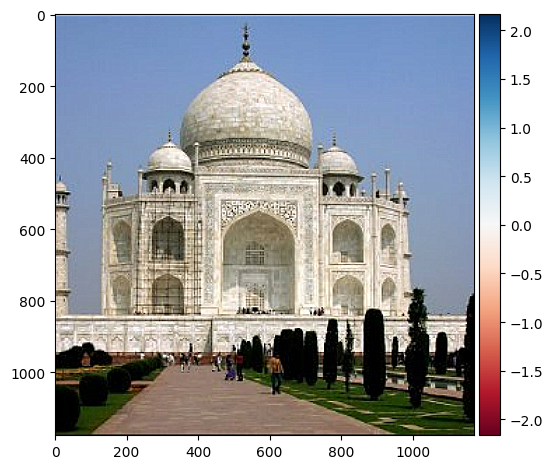

In [45]:
skio.imshow(sharpened)

In [46]:
cat =  skio.imread("../images/cat.JPG")
cat = sk.img_as_float(cat) 
cat = scipy.ndimage.rotate(cat, angle=-90, reshape=True, order=1, mode='constant', cval=0.0)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.39668718163611466..1.4104176049584072].


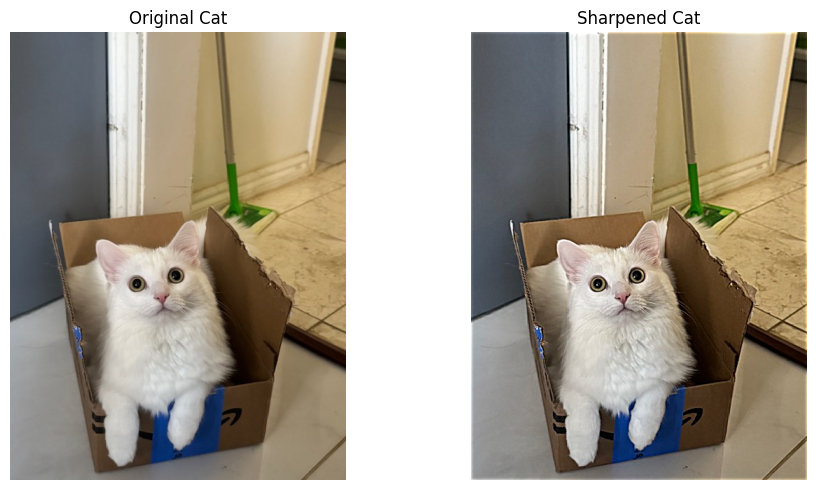

In [47]:
cat_unsharp_kernel = -1 * gaussian_2d
center = gaussian_2d.shape[0] // 2
cat_unsharp_kernel[center, center] += 2  

cats = np.zeros(cat.shape)
for color in range(cat.shape[2]):
    cats[:,:,color] = scipy.signal.convolve2d(cat[:,:,color], cat_unsharp_kernel, mode='same')
    
# Show both cat and cats (sharpened cat) in a 1x2 plot
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].imshow(cat)
axs[0].set_title('Original Cat')
axs[0].axis('off')
axs[1].imshow(cats)
axs[1].set_title('Sharpened Cat')
axs[1].axis('off')
plt.tight_layout()
plt.show()

#### 2.2

In [48]:
sys.path.append(os.path.join(os.path.dirname(os.getcwd()), 'hybrid_python'))

from align_image_code import *

In [60]:
#first try it with derek and nutmeg
derek_align = skio.imread('../hybrid_python/derek_aligned.jpg')
derek_align = sk.img_as_float(derek_align)
nutmeg_align = skio.imread('../hybrid_python/nutmeg_aligned.jpg')
nutmeg_align = sk.img_as_float(nutmeg_align)

In [153]:
#experiment with gaussian hyperparams
kernel_size = 15  # odd number
sigma = 5
# Create 2D Gaussian kernel using scipy
hybrid_gauss = signal.windows.gaussian(kernel_size, sigma)
hybrid_gauss = hybrid_gauss.reshape(-1, 1) @ hybrid_gauss.reshape(1, -1)
hybrid_gauss = hybrid_gauss / np.sum(hybrid_gauss)  

In [154]:
#do high on derek, low on cat
# Calculate both low and high frequencies for both derek and nutmeg
derek_low = np.stack([scipy.signal.convolve2d(derek_align[:,:,color], hybrid_gauss, mode='same') for color in range(derek_align.shape[2])], axis=2)
derek_high = derek_align - derek_low

nutmeg_low = np.stack([scipy.signal.convolve2d(nutmeg_align[:,:,color], hybrid_gauss, mode='same') for color in range(nutmeg_align.shape[2])], axis=2)
nutmeg_high = nutmeg_align - nutmeg_low

Note: had to multiply by an alpha to make the high pass more prevalent

Alternatively, increased sigma, and as sigma got higher the blend became more apparent

In [158]:
HYBRID_ALPHA = 3
dhnl = derek_high + nutmeg_low
dlnh = derek_low + HYBRID_ALPHA * nutmeg_high
dhnl_mean = (derek_high + nutmeg_low) / 2
dlnh_mean = (derek_low + nutmeg_high) / 2

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.1472702772724932..1.8278931585957514].


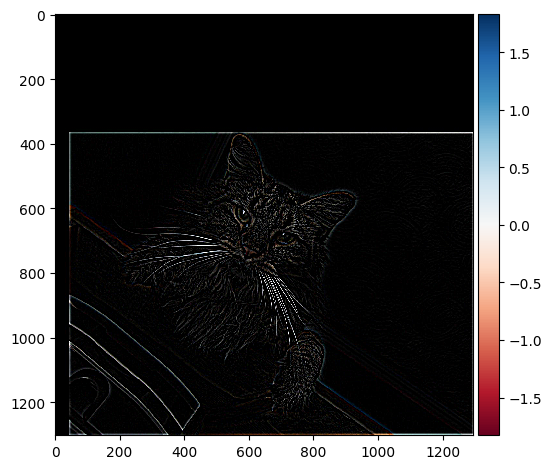

In [159]:
skio.imshow(HYBRID_ALPHA * nutmeg_high)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.19938615701705065..1.0720369809622925].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.1472702772724932..2.5506776231783412].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.09969307850852532..0.5360184904811462].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.19121171287874889..0.6960458823014993].


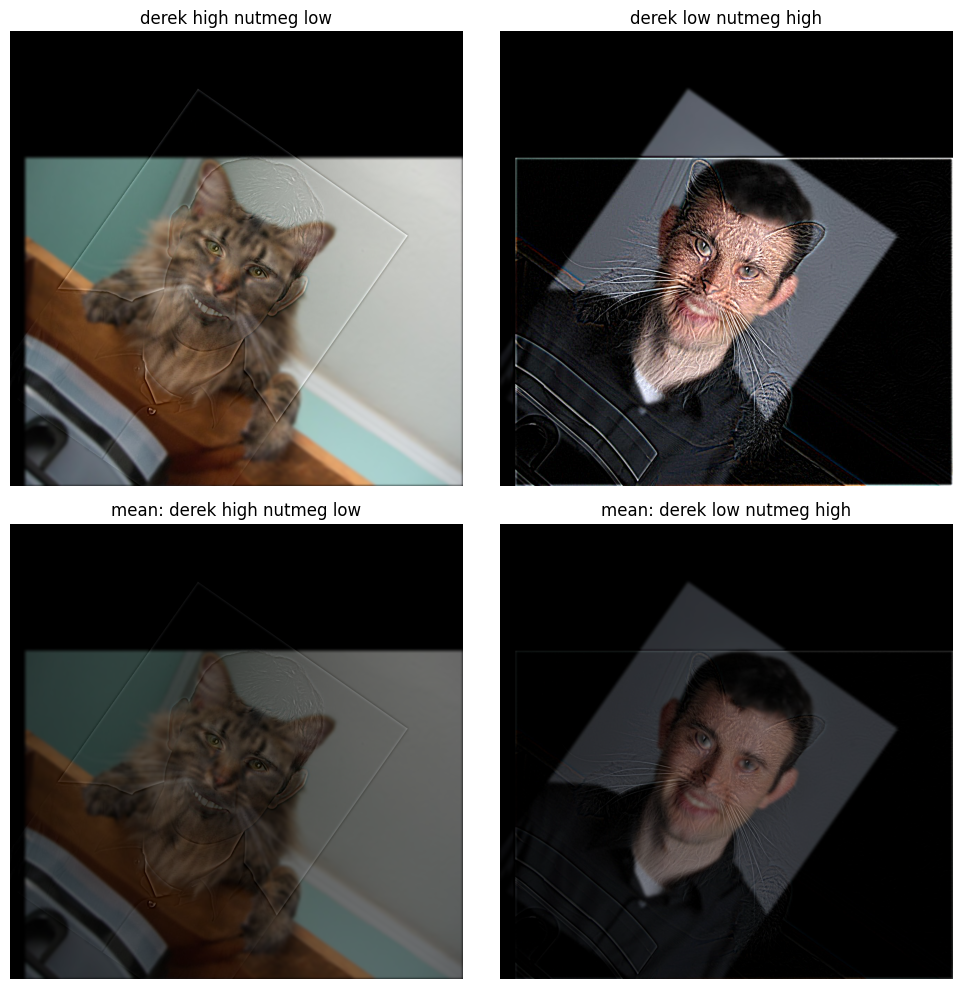

In [160]:
fig, axs = plt.subplots(2, 2, figsize=(10, 10))

axs[0, 0].imshow(dhnl)
axs[0, 0].set_title('derek high nutmeg low')
axs[0, 0].axis('off')

axs[0, 1].imshow(dlnh)
axs[0, 1].set_title('derek low nutmeg high')
axs[0, 1].axis('off')

axs[1, 0].imshow(dhnl_mean)
axs[1, 0].set_title('mean: derek high nutmeg low')
axs[1, 0].axis('off')

axs[1, 1].imshow(dlnh_mean)
axs[1, 1].set_title('mean: derek low nutmeg high')
axs[1, 1].axis('off')

plt.tight_layout()
plt.show()

In [166]:
chris = skio.imread('../images/chris.jpg')
chris = np.rot90(chris, k=-1)
chris = sk.img_as_float(chris)
sriram = skio.imread('../images/sriram.jpg')
sriram = np.rot90(sriram, k=-1) 
sriram = sk.img_as_float(sriram)

In [172]:
#Read in aligned
chris = skio.imread('../images/chris_aligned.jpg')
sriram = skio.imread('../images/sriram_aligned.jpg')
chris = sk.img_as_float(chris)
sriram = sk.img_as_float(sriram)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.04496321098374384..1.3530100586512588].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.38262211325191936..1.139868560980187].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.02248160549187192..0.6765050293256294].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.19131105662595968..0.5699342804900935].


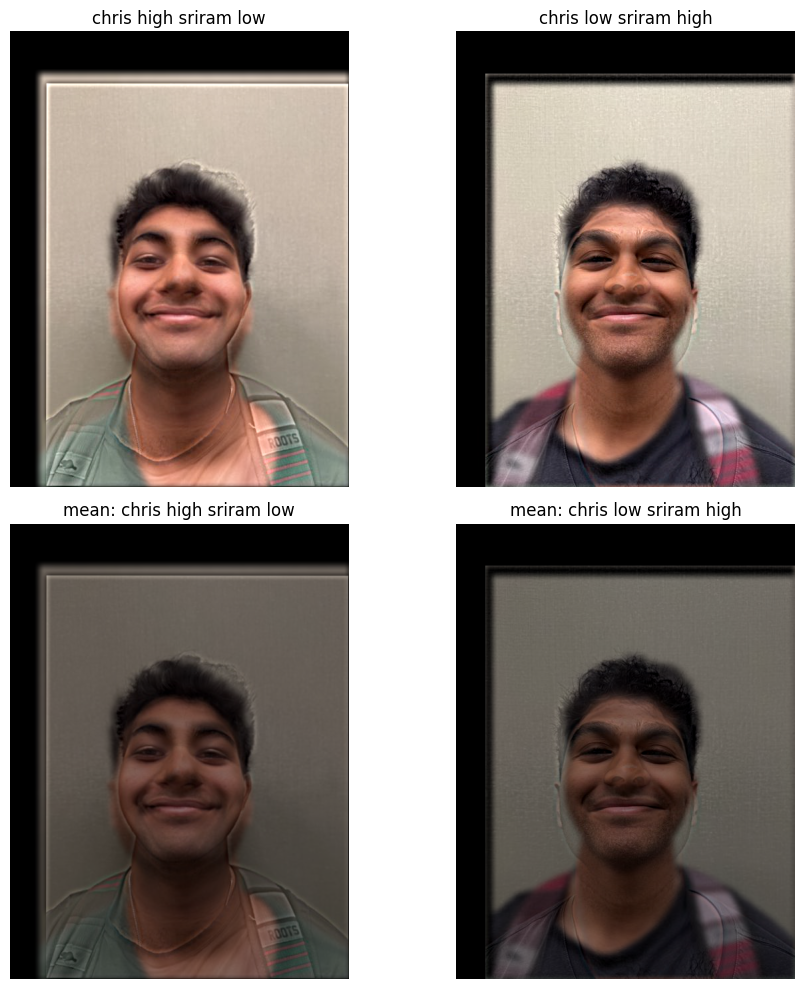

In [173]:
#do high on chris, low on sriram
# Calculate both low and high frequencies for both chris and sriram
chris_low = np.stack([scipy.signal.convolve2d(chris[:,:,color], hybrid_gauss, mode='same') for color in range(chris.shape[2])], axis=2)
chris_high = chris - chris_low

sriram_low = np.stack([scipy.signal.convolve2d(sriram[:,:,color], hybrid_gauss, mode='same') for color in range(sriram.shape[2])], axis=2)
sriram_high = sriram - sriram_low

HYBRID_ALPHA = 3
chnl = chris_high + sriram_low
clnh = chris_low +  sriram_high
chnl_mean = (chris_high + sriram_low) / 2
clnh_mean = (chris_low + sriram_high) / 2

fig, axs = plt.subplots(2, 2, figsize=(10, 10))

axs[0, 0].imshow(chnl)
axs[0, 0].set_title('chris high sriram low')
axs[0, 0].axis('off')

axs[0, 1].imshow(clnh)
axs[0, 1].set_title('chris low sriram high')
axs[0, 1].axis('off')

axs[1, 0].imshow(chnl_mean)
axs[1, 0].set_title('mean: chris high sriram low')
axs[1, 0].axis('off')

axs[1, 1].imshow(clnh_mean)
axs[1, 1].set_title('mean: chris low sriram high')
axs[1, 1].axis('off')

plt.tight_layout()
plt.show()

In [174]:
chnl.shape

(685, 509, 3)

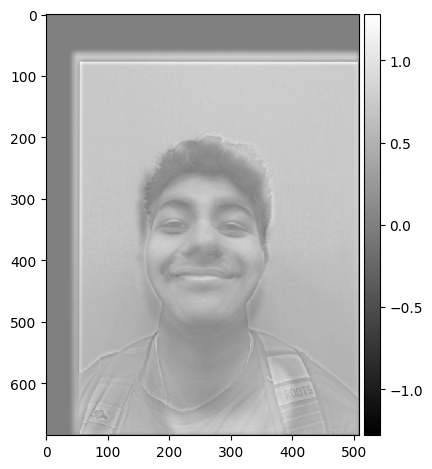

In [176]:
chnl_gray = np.mean(chnl, axis = 2)
skio.imshow(chnl_gray, cmap = 'gray')

### 2.3

### 2.4

In [ ]:
apple  
orange